In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
from scipy.interpolate import CubicSpline
#General RK4 method
def RK4(y, dty, t, dt):
  k1 = dty(t, y, x)
  k2 = dty(t + (0.5*dt), y + 0.5*dt*k1, x)
  k3 = dty(t + (0.5*dt), y + 0.5*dt*k2, x)
  k4 = dty(t + dt, y + dt*k3, x)

  y = y + (dt/6)*(k1+2*(k2+k3)+k4)
  t = t + dt
  return (y, t)

#this rate function is specifically the rate of change of y
def rate_function(t, y, x):
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # centered difference non boundary
    dyx[1:-1] = (y[2:] - y[:-2]) / (2 * h)

    # boundaries using periodic stuff
    dyx[0] = (y[1] - y[-1]) / (2 * h)
    dyx[-1] = (y[0] - y[-2]) / (2 * h)

    return - 1 * dyx #here v = 1

x = np.linspace(0, 0.99, 99)
y = np.sin(2 * np.pi * x)
dt = 0.01
t = 0
i = 0
frames_dir = 'animation_frames'
os.makedirs(frames_dir, exist_ok=True)

while t < 3:
  y, t = RK4(y, rate_function, t, dt)

  #plotting
  fig, ax = plt.subplots(figsize=(8, 8))

  ax.plot(x, y, color =  'blue', linewidth= 0.5)
  ax.plot(x, y, '.' ,color =  'blue')
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_title(f't= {t:.2f}')

  ax.set_ylim(bottom = -1, top = 1)

  ax.grid()

  frame_filename = os.path.join(frames_dir, f'frame_{i:04d}.png')
  plt.savefig(frame_filename, dpi=100, bbox_inches='tight')
  plt.close(fig)
  i += 1
  #print(f'{(100*t/3):.3f}', '%')


In [ ]:
import glob
frame_files = sorted(glob.glob(os.path.join(frames_dir, 'frame_*.png')))
print(f"Found {len(frame_files)} frame files.")

fig, ax = plt.subplots(figsize=(8, 8))

def update(frame_path):
    ax.clear()
    try:
        img = mpimg.imread(frame_path)
        ax.imshow(img)
        ax.axis(False)
    except Exception as e:
        print(f"Error reading frame {frame_path}: {e}")
    return []

ani = animation.FuncAnimation(fig, update, frames=frame_files, blit=False, interval = 100)

animation_path = 'sph_animation.html'
ani.save(animation_path, writer=animation.HTMLWriter())
plt.close(fig)

from IPython.display import HTML
HTML(ani.to_html5_video())

Found 301 frame files.


/tmp/ipython-input-214784352.py:43: RuntimeWarning: divide by zero encountered in log2
  ax[0].plot(xplot[3],np.log2(z[3] - cs(xplot[3])), label = '400')
/tmp/ipython-input-214784352.py:44: RuntimeWarning: invalid value encountered in log2
  ax[0].plot(xplot[2],np.log2(z[2] - cs(xplot[2])), label = '200')
/tmp/ipython-input-214784352.py:45: RuntimeWarning: invalid value encountered in log2
  ax[0].plot(xplot[1],np.log2(z[1] - cs1(xplot[1])), label = '100')
/tmp/ipython-input-214784352.py:46: RuntimeWarning: invalid value encountered in log2
  ax[0].plot(xplot[0],np.log2(z[0] - cs2(xplot[0])), label = '50')


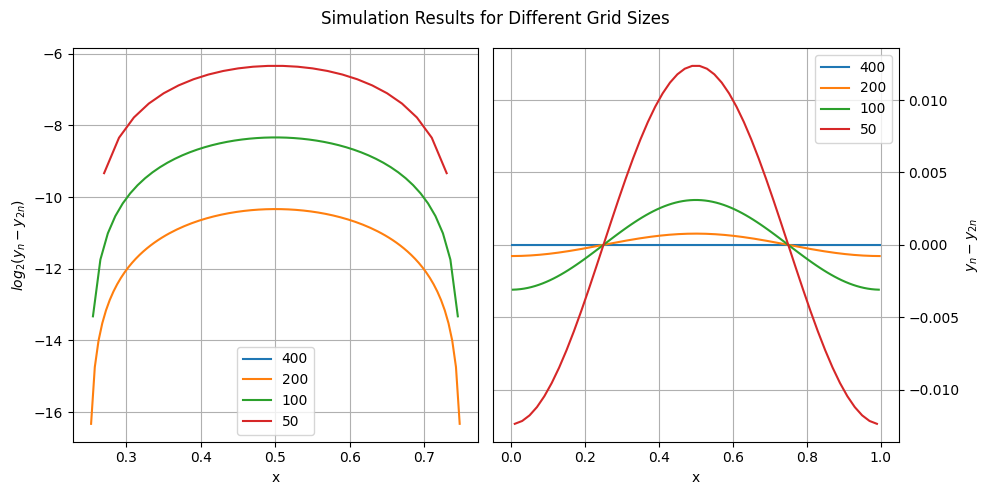

In [3]:
from scipy.interpolate import CubicSpline
# Define different numbers of grid points to test
grid_point_numbers = np.array([50, 100, 200,400])

# Store results for each grid size

def rate_function(t, y, x):
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # centered difference non boundary
    dyx[1:-1] = (y[2:] - y[:-2]) / (2 * h)

    # boundaries using periodic stuff
    dyx[0] = (y[1] - y[-1]) / (2 * h)
    dyx[-1] = (y[0] - y[-2]) / (2 * h)

    return dyx

z = []
xplot = []

for num in range(len(grid_point_numbers)):
  # set up x points
  x = np.linspace(0, (grid_point_numbers[num]-1)/grid_point_numbers[num] , grid_point_numbers[num])
  x += 1/(2*grid_point_numbers[num])
  #x = x[:-1]
  y = np.sin(2 * np.pi * x)
  t = 0

  z.append(rate_function(t,y,x))
  xplot.append(x)

#get interpolated shit

cs =CubicSpline(xplot[3], z[3])
cs1 =CubicSpline(xplot[2], z[2])
cs2 =CubicSpline(xplot[1], z[1])
cs3 =CubicSpline(xplot[0], z[0])
fig, ax = plt.subplots(1,2,figsize=(10, 5))


ax[0].plot(xplot[3],np.log2(z[3] - cs(xplot[3])), label = '400')
ax[0].plot(xplot[2],np.log2(z[2] - cs(xplot[2])), label = '200')
ax[0].plot(xplot[1],np.log2(z[1] - cs1(xplot[1])), label = '100')
ax[0].plot(xplot[0],np.log2(z[0] - cs2(xplot[0])), label = '50')

#ax.set_yscale("log")
ax[0].set_xlabel('x')
ax[0].set_ylabel(r'$log_2(y_n-y_{2n})$')
#ax[0].set_title('Simulation Results for Different Grid Sizes')
ax[0].grid()
ax[0].legend()

ax[1].plot(xplot[3], (z[3] - cs(xplot[3])), label = '400')
ax[1].plot(xplot[2], (z[2] - cs(xplot[2])), label = '200')
ax[1].plot(xplot[1], (z[1] - cs1(xplot[1])), label = '100')
ax[1].plot(xplot[0], (z[0] - cs2(xplot[0])), label = '50')

#ax.set_yscale("log")
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].set_xlabel('x')
ax[1].set_ylabel(r'$y_n-y_{2n}$')
#ax[1].set_title('Simulation Results for Different Grid Sizes')
ax[1].grid()
ax[1].legend()

fig.suptitle('Simulation Results for Different Grid Sizes')
fig.tight_layout()
plt.show()

This whole bit is for testing for convergence via the L2 error, $$error = \sqrt{\frac{\sum^N_0 (y_{h}- y_{h/2})^2}{N}}$$

In [ ]:
import numpy as np
from scipy.interpolate import make_interp_spline

def get_L2_error(x, y, x_2n, y_2n):
    N = len(y)

    # Use 4th order interpolation (degree = 4)
    spline = make_interp_spline(x_2n, y_2n, k=4)
    y_2n_interp = spline(x)

    L2 = np.sqrt(np.sum((y - y_2n_interp)**2) / N)
    return L2


#General RK4 method
def RK4(y, dty, t, dt):
  k1 = dty(t, y, x)
  k2 = dty(t + (0.5*dt), y + 0.5*dt*k1, x)
  k3 = dty(t + (0.5*dt), y + 0.5*dt*k2, x)
  k4 = dty(t + dt, y + dt*k3, x)

  y = y + (dt/6)*(k1+2*(k2+k3)+k4)
  t = t + dt
  return (y, t)

#this rate function is specifically the rate of change of y
def rate_function(t, y, x):
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # centered difference non boundary
    dyx[1:-1] = (y[2:] - y[:-2]) / (2 * h)

    # boundaries using periodic stuff
    dyx[0] = (y[1] - y[-1]) / (2 * h)
    dyx[-1] = (y[0] - y[-2]) / (2 * h)

    return - dyx #here v = 1

def centered_4th_order(t, y, x):
  h = x[1] - x[0]
  dyx = np.zeros_like(y)
  h12_inverse = 1 / (12 * h)
  # centered difference non boundary
  dyx[2:-2] = (-y[4:] + 8*y[3:-1] - 8*y[1:-3] + y[:-4]) * h12_inverse

  # boundaries using periodic stuff
  dyx[0] = (-y[2] + 8*(y[1] - y[-1]) + y[-2]) * h12_inverse
  dyx[1] = (-y[3] + 8*(y[2] - y[0]) + y[-1]) * h12_inverse
  dyx[-1] = (-y[1] + 8*(y[0] - y[-2]) + y[-3]) * h12_inverse
  dyx[-2] = (-y[0] + 8*(y[-1] - y[-3]) + y[-4]) * h12_inverse
  return dyx

y0 = []

#set up x points
xnum = 15
x = np.linspace(0, (xnum-1)/xnum , xnum)
x += 1/(2*xnum)

y = np.sin(2 * np.pi * x)
dt = 0.0001/(4*xnum)
t = 0

end_time = 0.001
while t < end_time:
  y, t = RK4(y, rate_function, t, dt)
  y0.append(y)

xnum = 2*xnum
x = np.linspace(0, (xnum-1)/xnum , xnum)
x += 1/(2*xnum)

y = np.sin(2 * np.pi * x)
t = 0

y1 = []
t_plot1 = []
while t < end_time:
  y, t = RK4(y, rate_function, t, dt)
  y1.append(y)
  t_plot1.append(t)

xnum = 2*xnum
x = np.linspace(0, (xnum-1)/xnum , xnum)
x += 1/(2*xnum)

y = np.sin(2 * np.pi * x)
t = 0

y2 = []
t_plot2 = []
while t < end_time:
  y, t = RK4(y, rate_function, t, dt)
  y2.append(y)
  t_plot2.append(t)

In [ ]:
xnum0 = 15


x = np.linspace(0, (xnum0-1)/xnum0 , xnum0)
x += 1/(2*xnum0)

x1 = np.linspace(0, (2*xnum0-1)/(2*xnum0) , 2*xnum0)
x1 += 1/(2*xnum0*2)

x2 = np.linspace(0, (4*xnum0-1)/(4*xnum0) , 4*xnum0)
x2 += 1/(2*xnum0*4)

err = np.zeros(len(y0[:]))

for i in range(len(err)):
  err[i] = get_L2_error(x, y0[i], x1, y1[i])

err1 = np.zeros(len(y1[:]))

for i in range(len(err)):
  err1[i] = get_L2_error(x1, y1[i], x2, y2[i])

(1.9, 4.0)

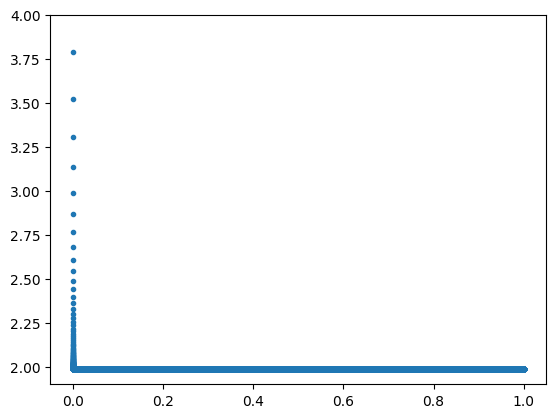

In [ ]:
plt.plot(t_plot1,np.log2(err/err1),'.')
plt.ylim(1.9,4)